In [61]:
import numpy as np
import pandas as pd
import seaborn as sns

In [45]:
df = pd.read_csv('/content/Social_Network_Ads.csv')

In [46]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


<Axes: xlabel='Age', ylabel='EstimatedSalary'>

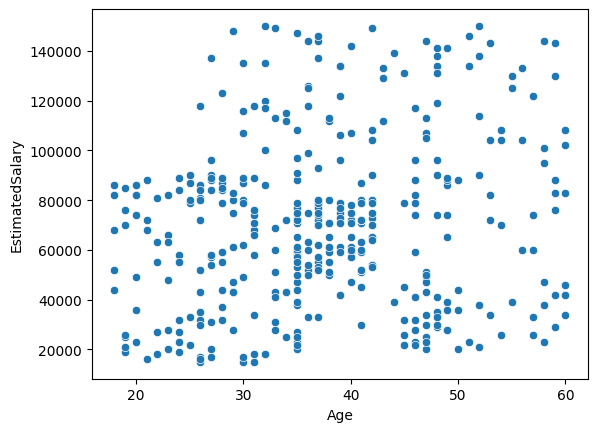

In [48]:
sns.scatterplot(x=df.iloc[:,0], y=df.iloc[:,1])

In [49]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [51]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [52]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [53]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 513 (2.00 KB)

 Trainable params: 513 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [55]:
history = model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5312 - loss: 217.6783 - val_accuracy: 0.4000 - val_loss: 115.7001
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4906 - loss: 122.3290 - val_accuracy: 0.4000 - val_loss: 90.2877
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4781 - loss: 67.8371 - val_accuracy: 0.6000 - val_loss: 82.3721
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5562 - loss: 46.1726 - val_accuracy: 0.4000 - val_loss: 21.7904
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4844 - loss: 51.0886 - val_accuracy: 0.6000 - val_loss: 111.6525
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5156 - loss: 158.4687 - val_accuracy: 0.4000 - val_loss: 52.2030
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4594 - loss: 96.9612 - val_accuracy: 0.6000 - val_loss: 109.5765
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4969 - loss: 155.41

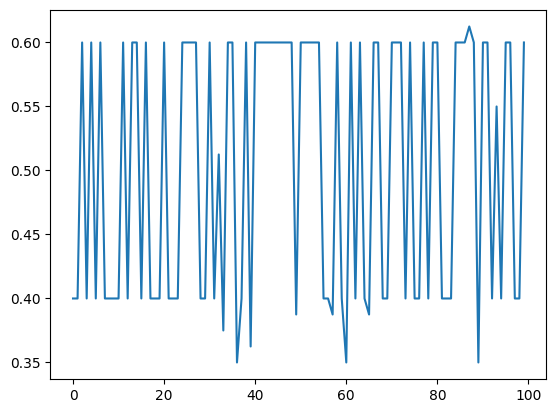

In [56]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])

**Applying Scaling**

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

<Axes: >

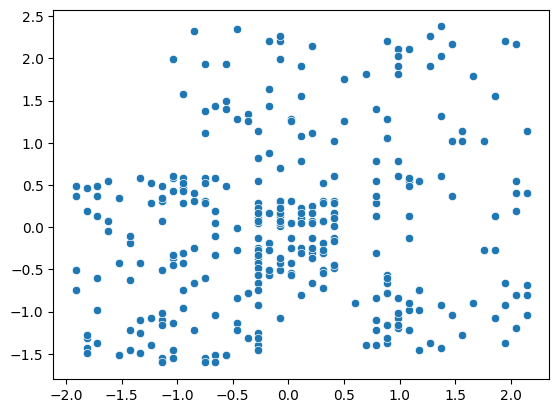

In [58]:
sns.scatterplot(x=X_train_scaled[:,0],y=X_train_scaled[:,1])

In [59]:
model = Sequential()

model.add(Dense(128,activation='relu',input_dim=2))
model.add(Dense(1,activation='sigmoid'))

model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

history = model.fit(X_train_scaled,y_train,validation_data=(X_test_scaled,y_test),epochs=100)

Epoch 1/100


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.7500 - loss: 0.6338 - val_accuracy: 0.7875 - val_loss: 0.6012
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7781 - loss: 0.5849 - val_accuracy: 0.7875 - val_loss: 0.5533
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7875 - loss: 0.5432 - val_accuracy: 0.7875 - val_loss: 0.5133
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8000 - loss: 0.5095 - val_accuracy: 0.8000 - val_loss: 0.4781
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8094 - loss: 0.4772 - val_accuracy: 0.8000 - val_loss: 0.4507
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.8156 - loss: 0.4509 - val_accuracy: 0.8000 - val_loss: 0.4252
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8281 - loss: 0.4264 - val_accuracy: 0.8125 - val_loss: 0.4044
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8375 - loss: 0.4046 - val_accuracy: 0.8250 - val_l

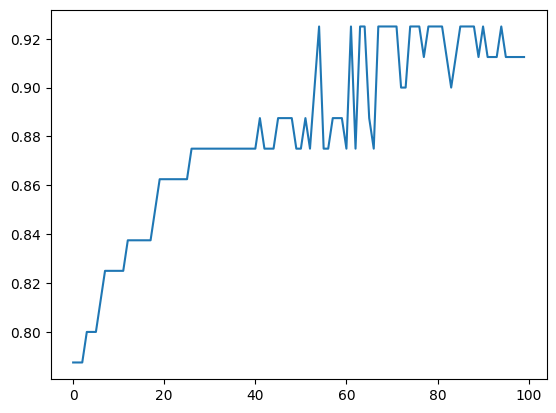

In [60]:
import matplotlib.pyplot as plt
plt.plot(history.history['val_accuracy'])